In [3]:
target_dir = "../data/raw/financial-fraud-detection-dataset"

In [5]:
import pandas as pd
import os

csv_file = os.path.join(target_dir, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print(f'\n')
print(df.head())

Looking for file at: ../data/raw/financial-fraud-detection-dataset\Synthetic_Financial_datasets_log.csv


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
# remove unuse columns
df.drop(['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'], axis=1, inplace=True)

In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('isFraud', axis=1),
                                                    df['isFraud'], test_size=0.2, random_state=101, stratify=df['isFraud'])

#initial dimensions and distribution of classes of train and test dataset
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(f'y_train fraud ratio: {y_train.value_counts(normalize= True)}')
print(y_test.value_counts())
print(f'y_test fraud ratio: {y_test.value_counts(normalize= True)}')

(5090096, 6)
(1272524, 6)
isFraud
0    5083526
1       6570
Name: count, dtype: int64
y_train fraud ratio: isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64
isFraud
0    1270881
1       1643
Name: count, dtype: int64
y_test fraud ratio: isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [17]:
#create a Random object so that it only affects whichever other objects uses it
import random
myrandom = random.Random(101)

#Performing random undersampling

removed_index = myrandom.sample(sorted(y_train[y_train==0].index), 5000000) #extracting the index of non-fraud rows that we want to remove from the training dataset
removed_X = X_train.loc[removed_index]
reduced_X = X_train.drop(removed_index)
removed_y = y_train[removed_index]
reduced_y = y_train.drop(removed_index)
new_X_test = pd.concat([X_test,removed_X]) #adding the index of rows that were removed into the test dataset
new_y_test = pd.concat([y_test,removed_y])

#dimensions and distributions of classes after undersampling
print(reduced_X.shape)
print(new_X_test.shape)
print(reduced_y.value_counts())

(90096, 6)
(6272524, 6)
isFraud
0    83526
1     6570
Name: count, dtype: int64


<BarContainer object of 2 artists>

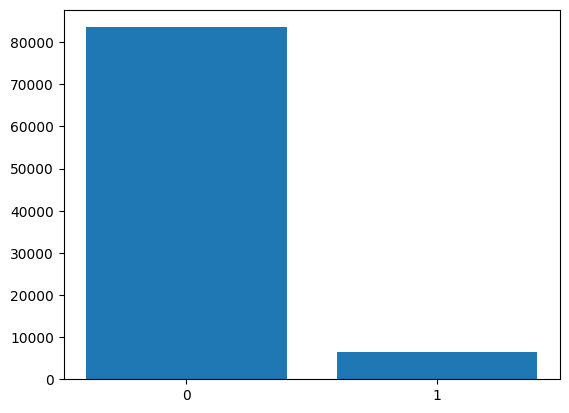

In [18]:
import matplotlib.pyplot as plt

#distribution of classes in training dataset
plt.bar([0,1], reduced_y.value_counts(), tick_label=[0,1])

<BarContainer object of 2 artists>

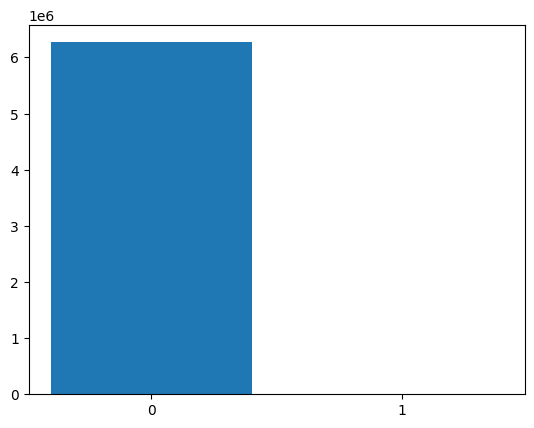

In [19]:
#distribution of classes in test dataset
plt.bar([0,1], new_y_test.value_counts(), tick_label=[0,1])

In [20]:
#checking the data distribution of each column to check for outliers as well as the magnitude in each column
reduced_X.describe()

,step,amount,isFlaggedFraud
count,90096.000000,9.009600e+04,90096.000000
mean,252.271288,2.706902e+05,0.000166
std,152.972380,9.238664e+05,0.012902
min,1.000000,0.000000e+00,0.000000
25%,156.000000,1.485314e+04,0.000000
50%,251.000000,8.658504e+04,0.000000
75%,349.000000,2.301273e+05,0.000000
max,743.000000,5.395754e+07,1.000000


In [22]:
# First, identify categorical columns
categorical_columns = reduced_X.select_dtypes(include=['object']).columns
numerical_columns = reduced_X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

# Encode categorical columns using one-hot encoding
X_train_encoded = pd.get_dummies(reduced_X, columns=categorical_columns)
X_test_encoded = pd.get_dummies(new_X_test, columns=categorical_columns)

# Ensure both train and test have same columns
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0

# Ensure columns are in the same order
X_test_encoded = X_test_encoded[X_train_encoded.columns]

Categorical columns: Index(['type', 'nameOrig', 'nameDest'], dtype='object')
Numerical columns: Index(['step', 'amount', 'isFlaggedFraud'], dtype='object')


MemoryError: Unable to allocate 7.08 GiB for an array with shape (90096, 84420) and data type bool

In [ ]:
#Use standardization/MinMaxScaler as some cols have outliers such as the consumption_levels
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train_scaled = minmax_scaler.fit_transform(reduced_X)
X_test_scaled = minmax_scaler.transform(new_X_test)

# Now apply scaling
minmax_scaler = MinMaxScaler()
X_train_scaled = minmax_scaler.fit_transform(X_train_encoded)
X_test_scaled = minmax_scaler.transform(X_test_encoded)

# Convert back to DataFrame to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

print("\nShape after encoding and scaling:")
print("Training data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)

ValueError: could not convert string to float: 'PAYMENT'

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Model Architecture Building
model = Sequential([
    Input(shape=(16,)),                       # 16 input features
    Dense(40, activation='relu'),
    Dropout(0.1),
    
    Dense(40, activation='relu'),
    Dropout(0.1),
    
    Dense(20, activation='relu'),
    Dropout(0.1),
    
    Dense(1, activation='sigmoid')            # Binary classification output
])

In [ ]:
model.summary()

In [ ]:
# Model Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',               # Appropriate for 0/1 fraud label
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Define Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# ✅ Optional: Handle Class Imbalance (if fraud cases are rare)
# For example, if fraud:non-fraud = 1:100, you can compute weights like this:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

In [ ]:
# Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score

In [ ]:
NN_pred = model.predict(X_test_scaled)

nn_pred = (NN_pred < 0.5).astype("int").flatten()

print(confusion_matrix(new_y_test, nn_pred))
print(classification_report(new_y_test, nn_pred))

In [ ]:
# Evaluate model performance
test_results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall: {test_results[3]:.4f}")
print(f"AUC: {test_results[4]:.4f}")

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_proba = model.predict(X_test).ravel()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()

# Precision–Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.show()